In [51]:
import astropy
import healpy as hp
import matplotlib.pyplot as plt 
import numpy as np
import shutil
from astropy.io import fits

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   56 / width of table in bytes                        NAXIS2  =                49152 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    7 / number of fields in each row                   EXTNAME = 'HPXEXPOSURES'       / name of this binary table extension            TELESCOP= 'GLAST   '                                                            INSTRUME= 'LAT     '                                                            COORDSYS= 'GAL     '                                                            ORDERING= 'RING    '                    

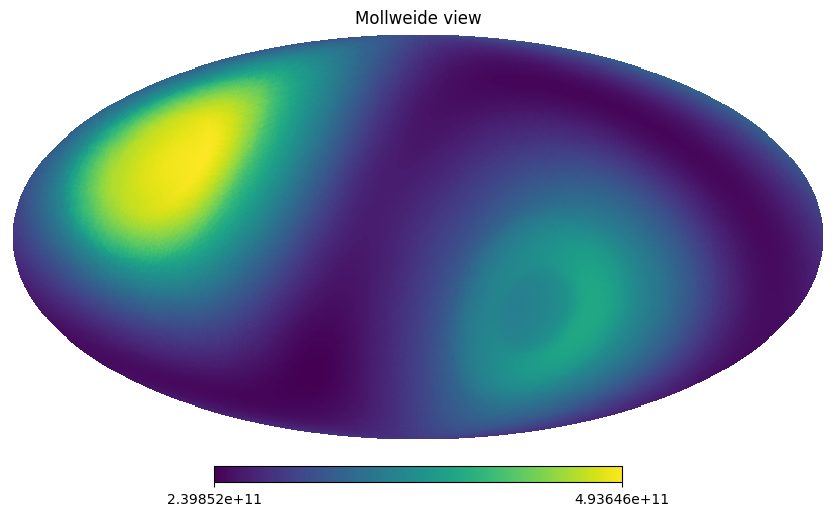

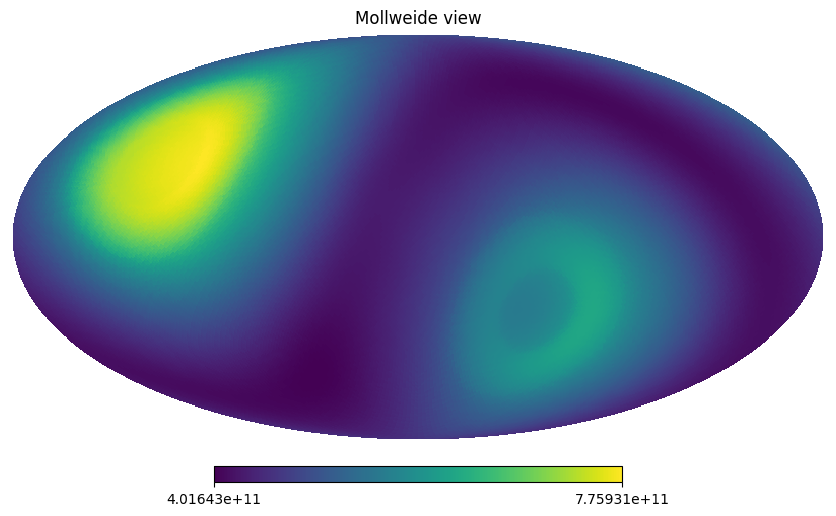

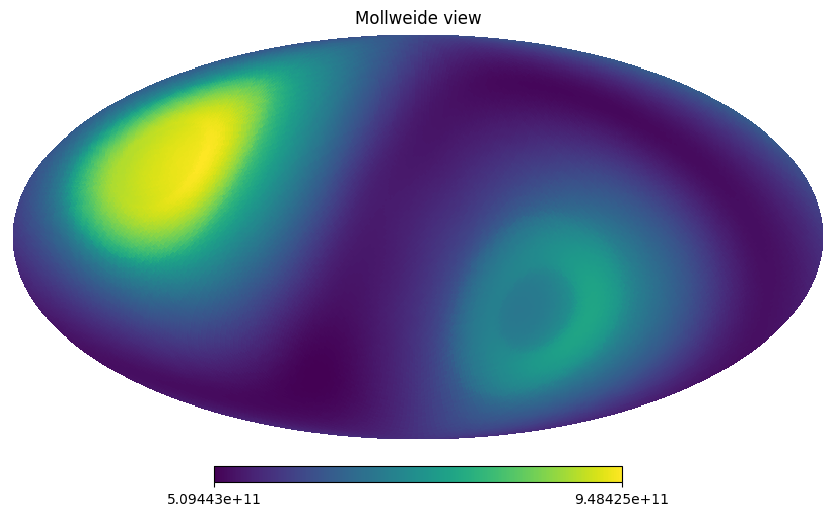

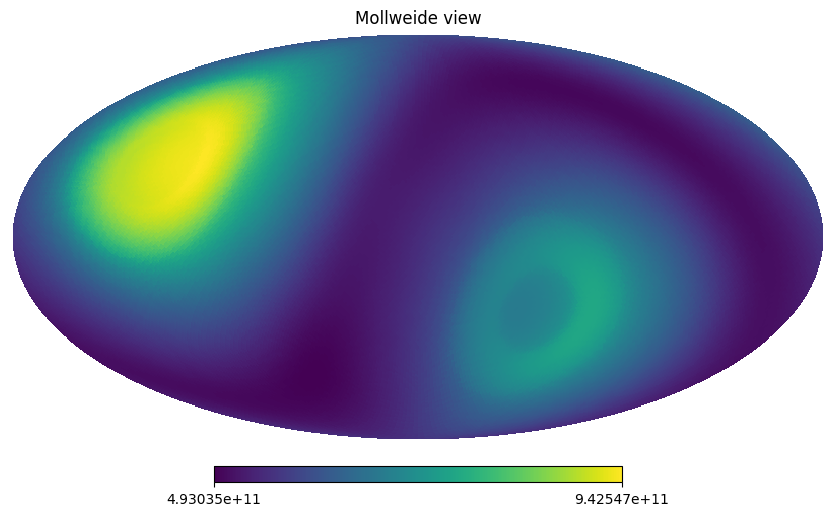

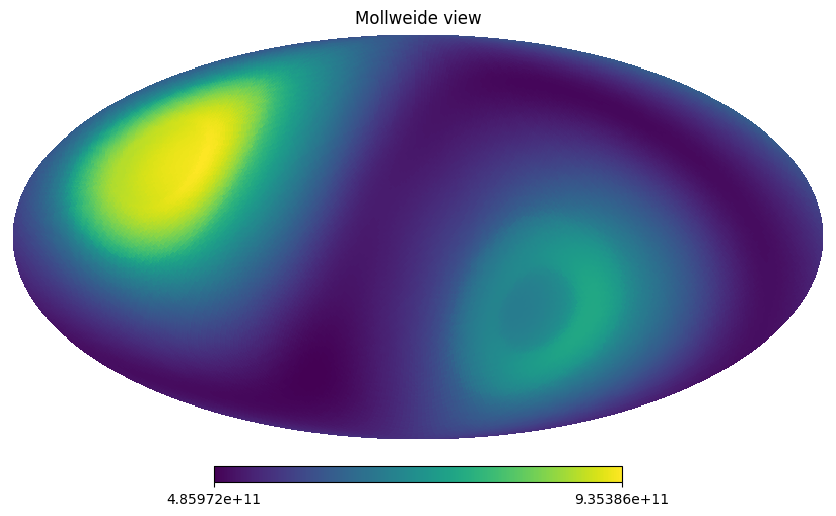

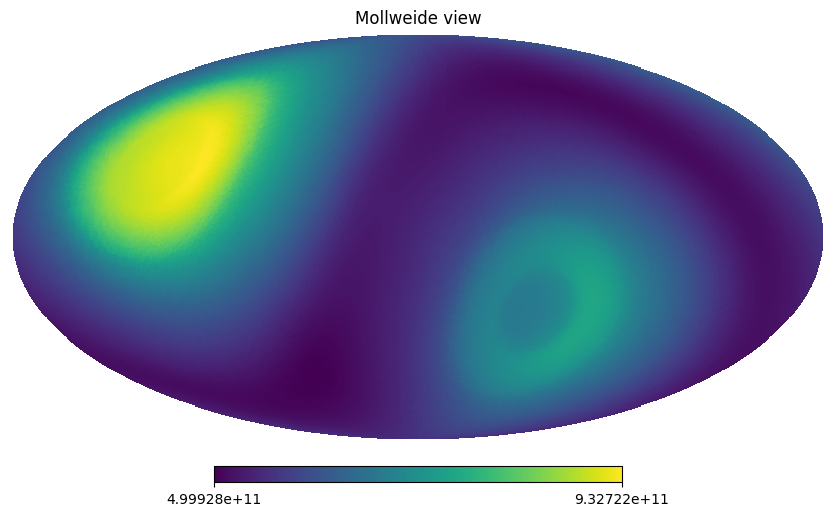

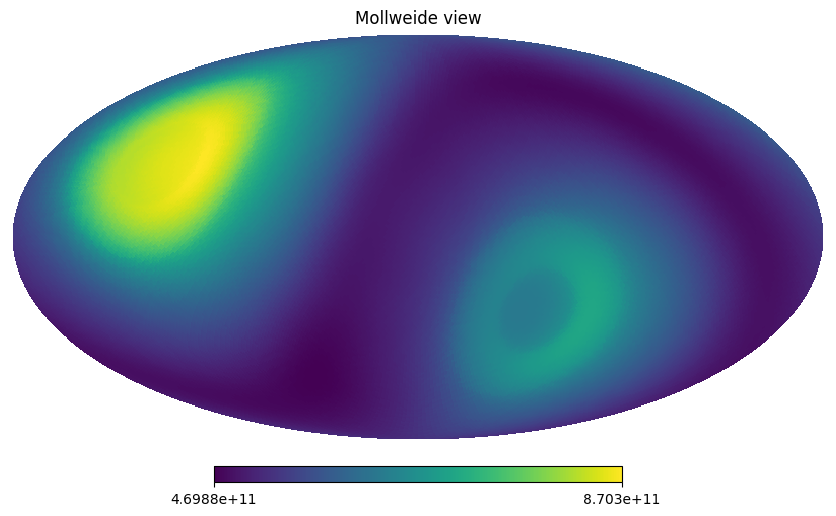

In [68]:
exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits") as hdul:
    
    print(hdul[1].header)
    
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=0))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=1))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=2))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=3))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=4))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=5))
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=6))

Filename: /Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   ()      
  1  HPXEXPOSURES    1 BinTableHDU     37   49152R x 7C   [D, D, D, D, D, D, D]   
  2  ENERGIES      1 BinTableHDU     13   7R x 1C   [1D]   
  3  GTI           1 BinTableHDU     18   98735R x 2C   [D, D]   
None
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   56 / width of table in bytes                        NAXIS2  =                49152 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    7 

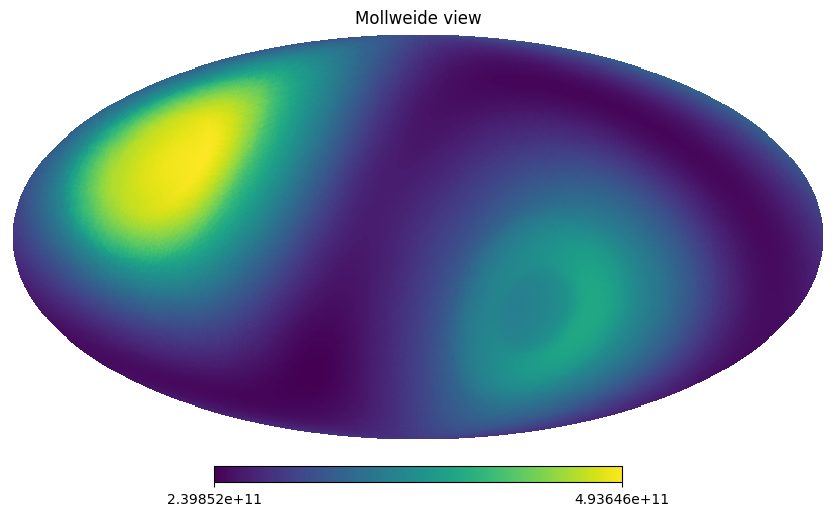

In [62]:
# Get number of bins

exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits") as hdul:
    
    print(hdul.info())
    
    print(hdul[1].header)
    
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES"))
    
with fits.open(exposure_file) as hdul:
    
    binned_map_data = hdul[0].data
    num_bins = binned_map_data.shape[0]
    energy_bin_boundaries = binned_map_data[1].data
    
    # exposure_map_1, header = hp.fitsfunc.read_map(exposure_file, h=True, hdu=1, field=(2))
    # 
    # print(hdul[0].header)
    
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
for k in range(num_bins - 1):
    
    new_file = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    shutil.copyfile(exposure_file, new_file)
            
    # Create separate binned data files
    with fits.open(new_file, mode='update') as hdul:
        
        binned_map_data = hdul[0].data
        
        healpix_map = binned_map_data[k]
        
        hdul[0].data = hdul[0].data[k]
                
        hdul.flush()


AttributeError: 'numpy.ndarray' object has no attribute 'field'

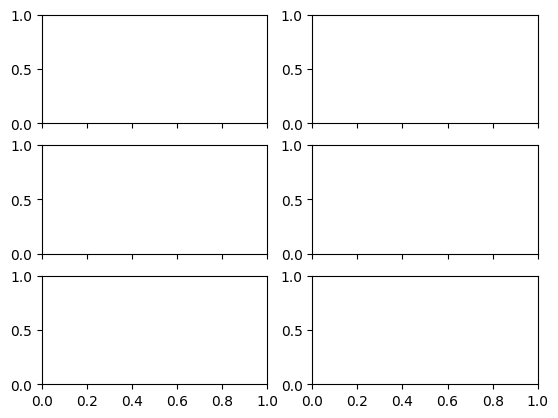

In [41]:
images = []

fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True)

# exposure_map_1 = hp.fitsfunc.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exposure_map_bin_0.fits", hdu=1, nest=False)
for k in range(num_bins - 1):
    
    file_name = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    exposure_map_1 = hp.fitsfunc.read_map(file_name, hdu=0, nest=False)
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
    with fits.open(file_name, mode='update') as hdul:
        
        i = k // 2
        j = k % 2
        
        data = hdul[0].data
        
        print(hdul[0].header)
        
        energy_bin_boundaries = np.array([k[0] for k in np.array(hdul[1].data)])
                
        images.append(data)
                
    ax[i][j].imshow(data, cmap='gray')
    
    ax[i, j].set_title("{} to {} MeV".format(np.round(energy_bin_boundaries[k], 2), np.round(energy_bin_boundaries[k + 1], 2)))
    
fig.suptitle("Exposure Maps")

ax = np.ravel(ax)

for a in ax:
    a.set_axis_off()

fig.tight_layout()

plt.show()

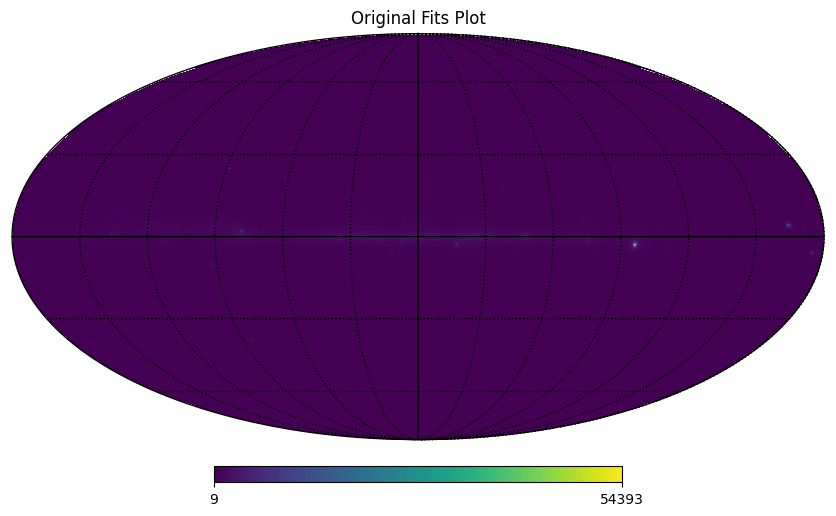

In [17]:
# hp.mollview(exposure_map, title='Original Fits Plot')
# hp.graticule()